In [1]:
"""
FINUFFT
Here I provide a first try at getting FINUFFT to work. The first step is to install finufft on Tycho,
as far as I recall I simply did

pip install finufft
"""

import finufft
import paicos as pa
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
%matplotlib widget

# Load a snapshot and select spherical region (?)
# snap = pa.Snapshot('/lustre/astro/berlok/zoom-simulations-new-ics/halo_0003/adiabatic-mhd/zoom4_ics_v1/output', 247)
# snap = pa.Snapshot(pa.data_dir, 247)
# center = snap.Cat.Group['GroupPos'][0]
# R200c = snap.Cat.Group['Group_R_Crit200'][0]
# r_max = 1.0 * R200c
# # index = pa.util.get_index_of_radial_range(snap['0_Coordinates'], center, 0., r_max)

# widths = np.array([2e3, 2e3, 2e3], dtype=float)
# index = pa.util.get_index_of_cubic_region(snap['0_Coordinates'], center, widths, snap.box)
# snap = snap.select(index, parttype=0)



In [2]:
def power_spectrum_1d(kvec, vhat):
    N = kvec.shape[0]
    M = kvec.shape[0]//2 + 1
    powerspectr = np.zeros(M)
    k1d = np.arange(0, M)
    for i in range(M):
        k_tmp = np.sqrt(kvec**2).astype(dtype='int')
        indices = np.argwhere(k_tmp==k1d[i])
        if (indices.size != 0):
            powerspectr[i] = np.sum((vhat[indices]*np.conj(vhat[indices])).real)/(N*N)
    return powerspectr, k1d

In [3]:
# # from scipy.stats import truncnorm

# # try 1d case
# N = 128
# # xx = 2.0*np.pi*np.random.uniform(size=N)
# xx_uniform = 2.0*np.pi*np.linspace(0,1,N)


# ### non-uniform grid with gaussian sampling
# # xx = np.random.normal(loc=np.pi, scale=np.pi/2, size=(N))
# # xx[xx>2.0*np.pi] = xx[xx>2.0*np.pi]%(2.0*np.pi)
# # xx[xx<0.0] = 2.0*np.pi-(-xx[xx<0.0]%(2.0*np.pi))
# ### test with uniform grid
# xx = 2.0*np.pi*np.linspace(0,1,N)

# vec1d = np.ones((N,), dtype='complex128')
# vec1d_uniform = np.ones((N,), dtype='complex128')

# # vec1d += 1.0
# # vec1d_uniform += 1.0

# for i in range(4,10):
#     rnd_amplitude = 0.1
#     rnd_phase     = np.random.uniform(size=1)*2.0*np.pi
#     rnd_phase = 0.0
#     vec1d += rnd_amplitude*(1/i**2)*np.exp(1j*xx*i + rnd_phase).real + 0.0j
#     vec1d_uniform += rnd_amplitude*(1/i**2)*np.exp(1j*xx_uniform*i + rnd_phase).real + 0.0j

# k1d_target = np.fft.fftfreq(N, d=1.0/N)
# vhat1d = finufft.nufft1d3(xx, vec1d, k1d_target, eps=1e-12)
# vhat1d_numpy = np.fft.fft(vec1d_uniform)

# powerspectr_numpy, k_shell = power_spectrum_1d(k1d_target, vhat1d_numpy)
# powerspectr_finufft, k_shell = power_spectrum_1d(k1d_target, vhat1d)



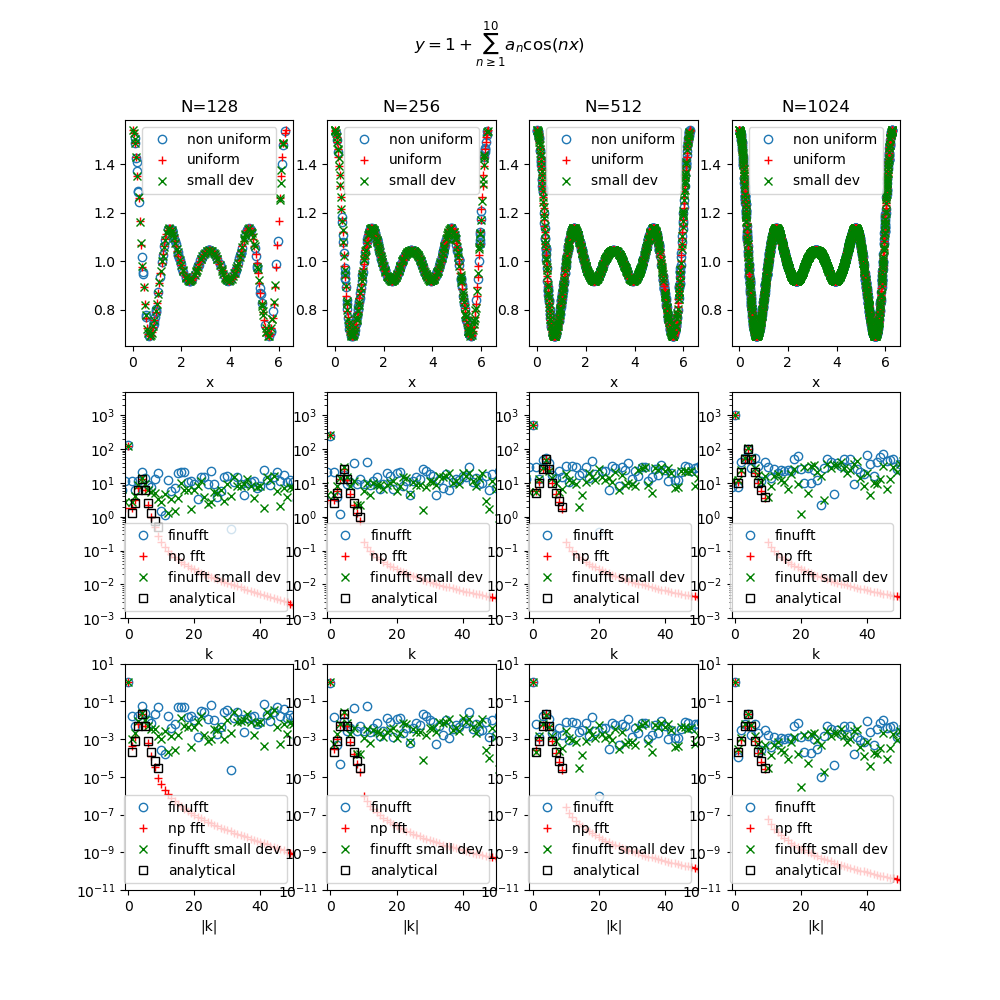

In [9]:
fig, ax = plt.subplots(3,4, figsize=(10,10))

for j in range(4):

    N = int(2**(j+7))
    # xx = 2.0*np.pi*np.random.uniform(size=N)
    xx_uniform = 2.0*np.pi*np.linspace(0,1,N)
    
    ### non-uniform grid with gaussian sampling
    # xx = np.random.normal(loc=np.pi, scale=np.pi, size=(N))
    # xx[xx>2.0*np.pi] = xx[xx>2.0*np.pi]%(2.0*np.pi)
    # xx[xx<0.0] = 2.0*np.pi-(-xx[xx<0.0]%(2.0*np.pi))
    ### non-uniform grid with flat sampling
    xx = 2.0*np.pi*np.random.uniform(size=(N))
    ### small random deviations from uniform grid
    xx_dev = xx_uniform*(1.0 + 0.01*np.random.normal(loc=0, scale=1, size=(N)))
    xx_dev[xx_dev>2.0*np.pi] = xx_dev[xx_dev>2.0*np.pi]%(2.0*np.pi)
    xx_dev[xx_dev<0.0] = 2.0*np.pi-(-xx_dev[xx_dev<0.0]%(2.0*np.pi))
    
    vec1d = np.ones((N,), dtype='complex128')
    vec1d_dev = np.ones((N,), dtype='complex128')
    vec1d_uniform = np.ones((N,), dtype='complex128')

    coeff = []
    for i in range(1,10):
        rnd_amplitude = 0.1
        rnd_phase     = np.random.uniform(size=1)*2.0*np.pi
        rnd_phase = 0.0
        vec1d += rnd_amplitude*(1/(1 + (i-4)**2))*np.exp(1j*xx*i + rnd_phase).real + 0.0j \
                + rnd_amplitude*(1/(1 + (i-4)**2))*np.exp(-1j*xx*i + rnd_phase).real
        vec1d_uniform += rnd_amplitude*(1/(1 + (i-4)**2))*np.exp(1j*xx_uniform*i + rnd_phase).real + 0.0j \
                        + rnd_amplitude*(1/(1 + (i-4)**2))*np.exp(-1j*xx_uniform*i + rnd_phase).real 
        vec1d_dev += rnd_amplitude*(1/(1 + (i-4)**2))*np.exp(1j*xx_dev*i + rnd_phase).real + 0.0j \
                        + rnd_amplitude*(1/(1 + (i-4)**2))*np.exp(-1j*xx_dev*i + rnd_phase).real 
        coeff.append(rnd_amplitude*(1/(1 + (i-4)**2)))
    
    k1d_target = np.fft.fftfreq(N, d=1.0/N)
    vhat1d = finufft.nufft1d3(xx, vec1d, k1d_target, eps=1e-12)
    vhat1d_dev = finufft.nufft1d3(xx_dev, vec1d_dev, k1d_target, eps=1e-12)
    vhat1d_numpy = np.fft.fft(vec1d_uniform)
    
    powerspectr_numpy, k_shell = power_spectrum_1d(k1d_target, vhat1d_numpy)
    powerspectr_finufft, k_shell = power_spectrum_1d(k1d_target, vhat1d)
    powerspectr_finufft_dev, k_shell = power_spectrum_1d(k1d_target, vhat1d_dev)

    ax[0,j].plot(xx, vec1d.real, ls='', marker='o', markerfacecolor='none', label='non uniform')
    ax[0,j].plot(xx_uniform, vec1d_uniform.real, ls='', marker='+', color='r', markerfacecolor='none', label='uniform')
    ax[0,j].plot(xx_dev, vec1d_dev.real, ls='', marker='x', color='g', markerfacecolor='none', label='small dev')
    ax[0,j].set_xlabel('x')
    
    ax[1,j].plot(k1d_target, np.abs(vhat1d), ls='', marker='o', markerfacecolor='none', label='finufft')
    ax[1,j].plot(k1d_target, np.abs(vhat1d_numpy), ls='', marker='+', color='r', markerfacecolor='none', label='np fft')
    ax[1,j].plot(k1d_target, np.abs(vhat1d_dev), ls='', marker='x', color='g', markerfacecolor='none', label='finufft small dev')
    ax[1,j].plot(np.arange(1,10), (N)*np.array(coeff), ls='', marker='s', color='k', markerfacecolor='none', label='analytical')
    ax[1,j].set_xlabel('k')
    ax[1,j].set_yscale('log')
    
    ax[2,j].plot(k_shell, powerspectr_finufft, ls='', marker='o', markerfacecolor='none', label='finufft')
    ax[2,j].plot(k_shell, powerspectr_numpy, ls='', marker='+', color='r', markerfacecolor='none', label='np fft')
    ax[2,j].plot(k_shell, powerspectr_finufft_dev, ls='', marker='x', color='g', markerfacecolor='none', label='finufft small dev')
    ax[2,j].plot(np.arange(1,10), 2.0*np.array(coeff)**2, ls='', marker='s', color='k', markerfacecolor='none', label='analytical')
    ax[2,j].set_xlabel('|k|')
    ax[2,j].set_yscale('log')
    
    ax[0,j].legend()
    ax[1,j].legend()
    ax[2,j].legend()
    
    ax[0,j].set_title('N=%d'%(N))

    ax[1,j].set_ylim(ymin=1e-3, ymax=5e3)
    ax[2,j].set_ylim(ymin=1e-11, ymax=1e1)
    
    ax[1,j].set_xlim(xmin=-1, xmax=50)
    ax[2,j].set_xlim(xmin=-1, xmax=50)

fig.suptitle(r'$y = 1 + \sum_{n \geq 1}^{10} a_n \cos (n x) $')

plt.show()



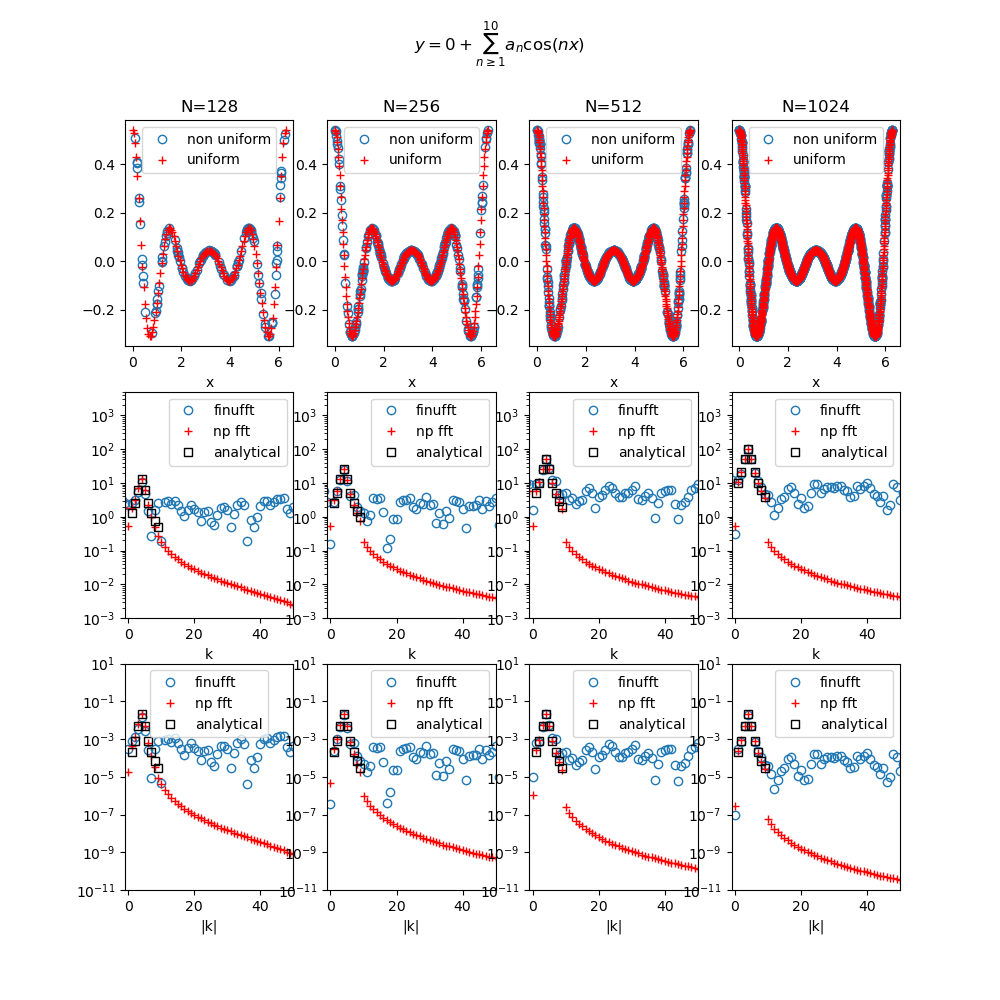

In [5]:
fig, ax = plt.subplots(3,4, figsize=(10,10))

for j in range(4):

    N = int(2**(j+7))
    xx_uniform = 2.0*np.pi*np.linspace(0,1,N)
    
    ### non-uniform grid with gaussian sampling
    # xx = np.random.normal(loc=np.pi, scale=np.pi, size=(N))
    # xx[xx>2.0*np.pi] = xx[xx>2.0*np.pi]%(2.0*np.pi)
    # xx[xx<0.0] = 2.0*np.pi-(-xx[xx<0.0]%(2.0*np.pi))
    ### non-uniform grid with flat sampling
    xx = 2.0*np.pi*np.random.uniform(size=(N))
    
    vec1d = np.zeros((N,), dtype='complex128')
    vec1d_uniform = np.zeros((N,), dtype='complex128')

    coeff = []
    for i in range(1,10):
        rnd_amplitude = 0.1
        rnd_phase     = np.random.uniform(size=1)*2.0*np.pi
        rnd_phase = 0.0
        vec1d += rnd_amplitude*(1/(1 + (i-4)**2))*np.exp(1j*xx*i + rnd_phase).real + 0.0j \
                + rnd_amplitude*(1/(1 + (i-4)**2))*np.exp(1j*xx*i + rnd_phase).real
        vec1d_uniform += rnd_amplitude*(1/(1 + (i-4)**2))*np.exp(1j*xx_uniform*i + rnd_phase).real + 0.0j \
                        + rnd_amplitude*(1/(1 + (i-4)**2))*np.exp(-1j*xx_uniform*i + rnd_phase).real 
        coeff.append(rnd_amplitude*(1/(1 + (i-4)**2)))
    
    k1d_target = np.fft.fftfreq(N, d=1.0/N)
    vhat1d = finufft.nufft1d3(xx, vec1d, k1d_target, eps=1e-12)
    vhat1d_numpy = np.fft.fft(vec1d_uniform)
    
    powerspectr_numpy, k_shell = power_spectrum_1d(k1d_target, vhat1d_numpy)
    powerspectr_finufft, k_shell = power_spectrum_1d(k1d_target, vhat1d)

    ax[0,j].plot(xx, vec1d.real, ls='', marker='o', markerfacecolor='none', label='non uniform')
    ax[0,j].plot(xx_uniform, vec1d_uniform.real, ls='', marker='+', color='r', markerfacecolor='none', label='uniform')
    ax[0,j].set_xlabel('x')
    
    ax[1,j].plot(k1d_target, np.abs(vhat1d), ls='', marker='o', markerfacecolor='none', label='finufft')
    ax[1,j].plot(k1d_target, np.abs(vhat1d_numpy), ls='', marker='+', color='r', markerfacecolor='none', label='np fft')
    ax[1,j].plot(np.arange(1,10), (N)*np.array(coeff), ls='', marker='s', color='k', markerfacecolor='none', label='analytical')
    ax[1,j].set_xlabel('k')
    ax[1,j].set_yscale('log')
    
    ax[2,j].plot(k_shell, powerspectr_finufft, ls='', marker='o', markerfacecolor='none', label='finufft')
    ax[2,j].plot(k_shell, powerspectr_numpy, ls='', marker='+', color='r', markerfacecolor='none', label='np fft')
    ax[2,j].plot(np.arange(1,10), 2.0*np.array(coeff)**2, ls='', marker='s', color='k', markerfacecolor='none', label='analytical')
    ax[2,j].set_xlabel('|k|')
    ax[2,j].set_yscale('log')
    
    ax[0,j].legend()
    ax[1,j].legend()
    ax[2,j].legend()
    
    ax[0,j].set_title('N=%d'%(N))

    ax[1,j].set_ylim(ymin=1e-3, ymax=5e3)
    ax[2,j].set_ylim(ymin=1e-11, ymax=1e1)
    
    ax[1,j].set_xlim(xmin=-1, xmax=50)
    ax[2,j].set_xlim(xmin=-1, xmax=50)

fig.suptitle(r'$y = 0 + \sum_{n \geq 1}^{10} a_n \cos (n x) $')

plt.show()

